In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

pd.set_option('display.max_columns', None)

In [3]:

df = pd.read_csv(r"C:\Users\avanindra Bose\OneDrive\Desktop\Real State Project\Cleaned Datasets\gurgaon_properties_missing_value_imputation.csv")

In [4]:
df.head(5)

,property_type,society,sector,price,price_per_square_feet,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,rof aalayas,sector 102,0.45,6000.0,1,1,2,6.0,Relatively New,750.0,0,0,0,0,0,1,0
1,house,huda sector-56 gurgaon,sector 56,3.60,24845.0,5,5,3+,3.0,Moderately Old,1449.0,0,0,0,0,1,1,47
2,flat,parsvnath green ville,sector 48,2.50,12820.0,4,5,3,1.0,Moderately Old,2167.0,0,0,0,0,1,0,49
3,flat,emaar gurgaon greens,sector 102,1.35,8181.0,3,3,3,5.0,Relatively New,1315.0,0,1,0,0,0,1,119
4,flat,raheja sampada,sector 92,0.65,4744.0,3,2,3,6.0,Relatively New,1240.0,0,0,0,0,0,1,49


In [5]:
df.sample(5)

,property_type,society,sector,price,price_per_square_feet,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
960,flat,dlf the ultima,sector 81,2.25,10553.0,3,3,3+,6.0,New Property,1929.0,0,1,0,0,0,2,168
1724,flat,ss,sector 85,2.10,7467.0,4,4,3,2.0,Relatively New,2600.0,0,0,0,0,0,1,49
3085,house,independent,sector 110,0.34,6800.0,1,1,0,1.0,Moderately Old,500.0,0,0,0,0,0,1,0
2276,flat,sobha city,sector 108,3.95,16859.0,4,5,3,25.0,Relatively New,2343.0,0,0,0,0,0,1,59
2296,flat,sobha city,sector 108,3.35,13266.0,3,4,2,19.0,New Property,2525.0,0,0,0,0,0,1,102


In [7]:
train_df = df.drop(columns=['society','price_per_square_feet'])

Removed society and price per square feet

1. We don't ask users to put society as our input -> if users want they can refer to websites.
2. We don't expect users to give price per square feet as an input. (We expect users to give price as input)

In [8]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 102,0.45,1,1,2,6.0,Relatively New,750.0,0,0,0,0,0,1,0
1,house,sector 56,3.60,5,5,3+,3.0,Moderately Old,1449.0,0,0,0,0,1,1,47
2,flat,sector 48,2.50,4,5,3,1.0,Moderately Old,2167.0,0,0,0,0,1,0,49
3,flat,sector 102,1.35,3,3,3,5.0,Relatively New,1315.0,0,1,0,0,0,1,119
4,flat,sector 92,0.65,3,2,3,6.0,Relatively New,1240.0,0,0,0,0,0,1,49


Handling 2 Columns -> Luxury Score and Floor Num. 

1. Converting luxury score to categorical column , because we dont want users to give numbers as an input and users dont understand what 54 or 103 luxury score represents.

2. Converting FloorNum to Categorical Column , We expect users to give us a categorical floorNum as an input (For Ex : High Risse , Low Rise) instead of direct floor Number.

Luxury

<Axes: xlabel='luxury_score'>

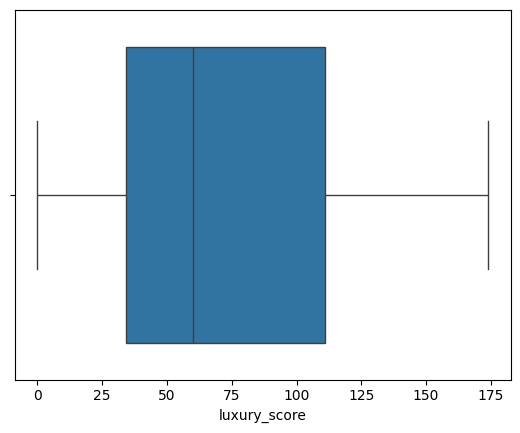

In [10]:
sns.boxplot(x=train_df['luxury_score'])

In [11]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [12]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [13]:

train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 102,0.45,1,1,2,6.0,Relatively New,750.0,0,0,0,0,0,1,0,Low
1,house,sector 56,3.60,5,5,3+,3.0,Moderately Old,1449.0,0,0,0,0,1,1,47,Low
2,flat,sector 48,2.50,4,5,3,1.0,Moderately Old,2167.0,0,0,0,0,1,0,49,Low
3,flat,sector 102,1.35,3,3,3,5.0,Relatively New,1315.0,0,1,0,0,0,1,119,Medium
4,flat,sector 92,0.65,3,2,3,6.0,Relatively New,1240.0,0,0,0,0,0,1,49,Low


Floor Num

<Axes: xlabel='floorNum'>

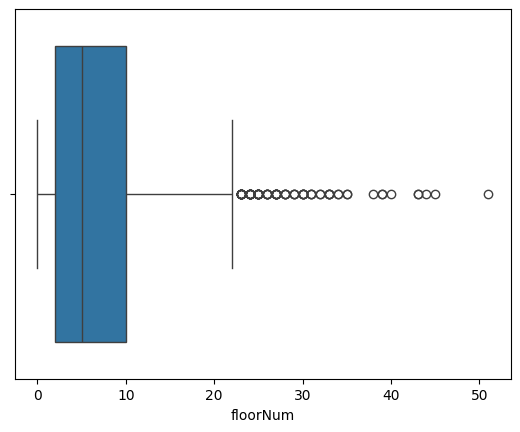

In [15]:
sns.boxplot(x = df['floorNum'])

In [16]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None 

In [17]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [18]:

train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 102,0.45,1,1,2,6.0,Relatively New,750.0,0,0,0,0,0,1,0,Low,Mid Floor
1,house,sector 56,3.60,5,5,3+,3.0,Moderately Old,1449.0,0,0,0,0,1,1,47,Low,Mid Floor
2,flat,sector 48,2.50,4,5,3,1.0,Moderately Old,2167.0,0,0,0,0,1,0,49,Low,Low Floor
3,flat,sector 102,1.35,3,3,3,5.0,Relatively New,1315.0,0,1,0,0,0,1,119,Medium,Mid Floor
4,flat,sector 92,0.65,3,2,3,6.0,Relatively New,1240.0,0,0,0,0,0,1,49,Low,Mid Floor


In [19]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [20]:

train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 102,0.45,1,1,2,Relatively New,750.0,0,0,0,0,0,1,Low,Mid Floor
1,house,sector 56,3.60,5,5,3+,Moderately Old,1449.0,0,0,0,0,1,1,Low,Mid Floor
2,flat,sector 48,2.50,4,5,3,Moderately Old,2167.0,0,0,0,0,1,0,Low,Low Floor
3,flat,sector 102,1.35,3,3,3,Relatively New,1315.0,0,1,0,0,0,1,Medium,Mid Floor
4,flat,sector 92,0.65,3,2,3,Relatively New,1240.0,0,0,0,0,0,1,Low,Mid Floor


Before Applying Feature Selection -> We should Convert our categorical Columns into Numercial using Ordinal Encoder.

Please Note that : For Linear Feature Selection Technique we muset use OHE(One Hot Encoding)

Since , we are majorly using Tree based Algorithms , so we can use Ordinal Encoder Here.

In [21]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sector 53', 'sector 54', 'sector 55', 'sector 5

In [23]:
X_label.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,4.0,1,1,2.0,3.0,750.0,0,0,0,0,0,1,1.0,2.0
1,1.0,62.0,5,5,4.0,0.0,1449.0,0,0,0,0,1,1,1.0,2.0
2,0.0,53.0,4,5,3.0,0.0,2167.0,0,0,0,0,1,0,1.0,1.0
3,0.0,4.0,3,3,3.0,3.0,1315.0,0,1,0,0,0,1,2.0,2.0
4,0.0,104.0,3,2,3.0,3.0,1240.0,0,0,0,0,0,1,1.0,2.0


In [25]:
y_label

0       0.45
1       3.60
2       2.50
3       1.35
4       0.65
        ... 
3548    2.00
3549    0.28
3550    9.00
3551    0.70
3552    6.50
Name: price, Length: 3553, dtype: float64

# Technique 1 -> Correlation Analysis

<Axes: >

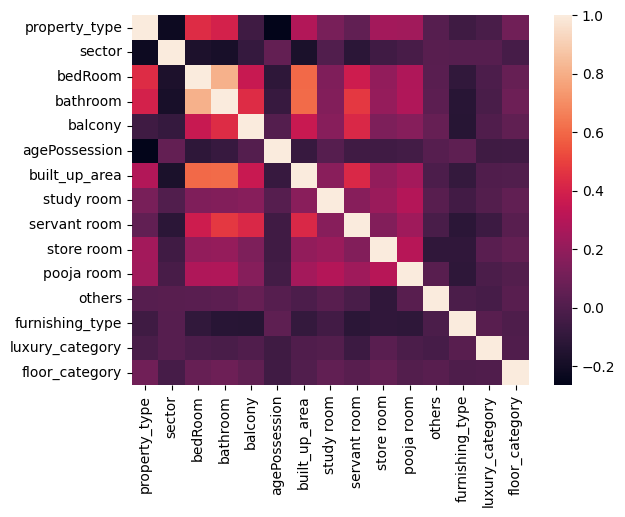

In [27]:
sns.heatmap(X_label.corr())

We Need analysis w.r.t Price. (Because Price will be our Output Column)

In [28]:
data_label_encoded.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,4.0,0.45,1,1,2.0,3.0,750.0,0,0,0,0,0,1,1.0,2.0
1,1.0,62.0,3.60,5,5,4.0,0.0,1449.0,0,0,0,0,1,1,1.0,2.0
2,0.0,53.0,2.50,4,5,3.0,0.0,2167.0,0,0,0,0,1,0,1.0,1.0
3,0.0,4.0,1.35,3,3,3.0,3.0,1315.0,0,1,0,0,0,1,2.0,2.0
4,0.0,104.0,0.65,3,2,3.0,3.0,1240.0,0,0,0,0,0,1,1.0,2.0


In [39]:
fi_df1 = data_label_encoded.corr()['price'].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})

In [40]:
fi_df1

,feature,corr_coeff
0,property_type,0.503683
1,sector,-0.202627
2,price,1.000000
3,bedRoom,0.591230
4,bathroom,0.609720
5,balcony,0.269554
6,agePossession,-0.133014
7,built_up_area,0.748545
8,study room,0.242890
9,servant room,0.391850


# Technique 2 Random Forest Feature Importance

In [43]:
from sklearn.ensemble import RandomForestRegressor 

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label,y_label)

fi_df2 = pd.DataFrame(
    {
        'feature' : X_label.columns,
        'rf_importance' : rf.feature_importances_
    }
).sort_values(by='rf_importance', ascending=False)

In [44]:
fi_df2

,feature,rf_importance
6,built_up_area,0.650766
1,sector,0.104855
0,property_type,0.102444
3,bathroom,0.025445
2,bedRoom,0.021499
8,servant room,0.020484
5,agePossession,0.013577
4,balcony,0.012693
12,furnishing_type,0.009613
7,study room,0.008960


# Technique 3 - Gradient Boosting Feature importances

In [47]:
from sklearn.ensemble import GradientBoostingRegressor 

gbr = GradientBoostingRegressor()
gbr.fit(X_label,y_label)

fi_df3 = pd.DataFrame(
    {
        'feature' : X_label.columns,
        'gbr_importance' : gbr.feature_importances_
    }
).sort_values(by='gbr_importance', ascending=False)

In [48]:
fi_df3 

,feature,gbr_importance
6,built_up_area,0.686018
1,sector,0.101626
0,property_type,0.097216
2,bedRoom,0.038329
3,bathroom,0.034783
8,servant room,0.020322
9,store room,0.010263
5,agePossession,0.004258
7,study room,0.002507
4,balcony,0.002282


# Technique 4 - Permutation Importance

In [49]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)


rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.706648
0,property_type,0.145056
1,sector,0.138909
8,servant room,0.014039
3,bathroom,0.007726
5,agePossession,0.005879
13,luxury_category,0.000945
4,balcony,0.000815
11,others,0.000620
9,store room,-0.002487


# Technique 5 - RFE (Recursive Feature Elimination)

In [50]:
from sklearn.feature_selection import RFE


estimator = RandomForestRegressor()


selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)


selected_features = X_label.columns[selector_label.support_]


selected_coefficients = selector_label.estimator_.feature_importances_

fi_df5 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df5

,feature,rfe_score
6,built_up_area,0.651886
1,sector,0.104161
0,property_type,0.098887
2,bedRoom,0.026637
3,bathroom,0.024234
8,servant room,0.019777
5,agePossession,0.014461
4,balcony,0.012436
12,furnishing_type,0.009951
13,luxury_category,0.008312


In [53]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature')

In [54]:
final_fi_df

,feature,corr_coeff,rf_importance,gbr_importance,permutation_importance,rfe_score
0,property_type,0.503683,0.102444,0.097216,0.145056,0.098887
1,sector,-0.202627,0.104855,0.101626,0.138909,0.104161
2,bedRoom,0.591230,0.021499,0.038329,-0.014968,0.026637
3,bathroom,0.609720,0.025445,0.034783,0.007726,0.024234
4,balcony,0.269554,0.012693,0.002282,0.000815,0.012436
5,agePossession,-0.133014,0.013577,0.004258,0.005879,0.014461
6,built_up_area,0.748545,0.650766,0.686018,0.706648,0.651886
7,study room,0.242890,0.008960,0.002507,-0.015474,0.007557
8,servant room,0.391850,0.020484,0.020322,0.014039,0.019777
9,store room,0.305642,0.006557,0.010263,-0.002487,0.007296


In [61]:
final_fi_df = final_fi_df.set_index("feature")
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1) -> This code normalizes each column so the sum = 1.

In [62]:
final_fi_df

,corr_coeff,rf_importance,gbr_importance,permutation_importance,rfe_score
feature,,,,,
property_type,0.141023,0.102444,0.097216,0.151105,0.098887
sector,-0.056732,0.104855,0.101626,0.144702,0.104161
bedRoom,0.165534,0.021499,0.038329,-0.015592,0.026637
bathroom,0.170711,0.025445,0.034783,0.008048,0.024234
balcony,0.075470,0.012693,0.002282,0.000849,0.012436
agePossession,-0.037242,0.013577,0.004258,0.006124,0.014461
built_up_area,0.209580,0.650766,0.686018,0.736115,0.651886
study room,0.068005,0.008960,0.002507,-0.016120,0.007557
servant room,0.109711,0.020484,0.020322,0.014624,0.019777


In [66]:
final_fi_df[['rf_importance','gbr_importance','permutation_importance','rfe_score']].mean(axis=1).sort_values(ascending=False)

feature
built_up_area      0.681196
sector             0.113836
property_type      0.112413
bathroom           0.023128
servant room       0.018802
bedRoom            0.017718
agePossession      0.009605
balcony            0.007065
store room         0.005381
luxury_category    0.004355
furnishing_type    0.004335
floor_category     0.002505
others             0.001590
study room         0.000726
pooja room        -0.002656
dtype: float64

On the combined final_fi_df we can see columns pooja room , study room , others can be dropped off because there overall result is too less.

We can also drop off floor_category -> But we need it as an input by the user

Before Dropping lets test it on an Algo.

In [68]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X_label,y_label,test_size=0.2,random_state=42)

In [72]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred = rf.predict(X_test)

In [76]:
r2_score(y_pred,y_test)

0.7849239335442934

In [ ]:
X_label.drop(columns=['pooja room' , 'study room' , 'others'],inplace=True)

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X_label,y_label,test_size=0.2,random_state=42)

In [84]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [85]:
y_pred = rf.predict(X_test)

In [86]:
r2_score(y_pred,y_test)

0.7941894515897927

We can notice that after removal of 3 columns -> r2_score was better , hence there is no point of keeping these columns

In [87]:
export_df = X_label
export_df['price'] = y_label

In [88]:
export_df.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,4.0,1,1,2.0,3.0,750.0,0,0,1,1.0,2.0,0.45
1,1.0,62.0,5,5,4.0,0.0,1449.0,0,0,1,1.0,2.0,3.60
2,0.0,53.0,4,5,3.0,0.0,2167.0,0,0,0,1.0,1.0,2.50
3,0.0,4.0,3,3,3.0,3.0,1315.0,1,0,1,2.0,2.0,1.35
4,0.0,104.0,3,2,3.0,3.0,1240.0,0,0,1,1.0,2.0,0.65


In [89]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)